<a href="https://colab.research.google.com/github/yadhvi13/AI-Website-Builder/blob/main/Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-3: Reverse Product Search



In [13]:
import os

for file in os.listdir("/content"):
    print(file)

.config
archive.zip
sample_data


In [14]:
# !unzip -q archive.zip
import os

if not os.path.exists("/content/images"):
    !unzip -q archive.zip
else:
    print("Dataset already extracted.")

In [15]:
import os

print(os.listdir("/content"))

['.config', 'myntradataset', 'styles.csv', 'images', 'archive.zip', 'sample_data']


In [16]:
import os

len(os.listdir("/content/images"))

44441

In [17]:
import pandas as pd

df = pd.read_csv("/content/styles.csv", on_bad_lines="skip")

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [18]:
!pip install -q sentence-transformers

In [19]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import os

In [20]:
df = df.fillna("")

In [21]:
df["description"] = (
    df["gender"].astype(str) + " " +
    df["baseColour"].astype(str) + " " +
    df["articleType"].astype(str) + " " +
    df["usage"].astype(str)
)

In [22]:
df[["productDisplayName", "description"]].head()

,productDisplayName,description
0,Turtle Check Men Navy Blue Shirt,Men Navy Blue Shirts Casual
1,Peter England Men Party Blue Jeans,Men Blue Jeans Casual
2,Titan Women Silver Watch,Women Silver Watches Casual
3,Manchester United Men Solid Black Track Pants,Men Black Track Pants Casual
4,Puma Men Grey T-shirt,Men Grey Tshirts Casual


In [23]:
model = SentenceTransformer("clip-ViT-B-32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [24]:
small_df = df.iloc[:5000].copy()

In [25]:
embeddings = model.encode(
    small_df["description"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [26]:
def search_product(query, top_k=5):

    query_embedding = model.encode([query])

    similarity = cosine_similarity(query_embedding, embeddings)[0]

    top_indices = similarity.argsort()[-top_k:][::-1]

    return small_df.iloc[top_indices]

In [27]:
results = search_product("blue casual shirt")

results[[
    "productDisplayName",
    "articleType",
    "baseColour"
]]

,productDisplayName,articleType,baseColour
1569,Flying Machine Men Check Blue Shirts,Shirts,Blue
837,U.S. Polo Assn. Men Striped Blue Shirt,Shirts,Blue
4551,Locomotive Men Solid Poplin Laird Blue Shirts,Shirts,Blue
891,United Colors of Benetton Men Solid Blue Shirts,Shirts,Blue
3926,Indigo Nation Men Reversible Bling Blue Shirts,Shirts,Blue


In [28]:
def show_results(query):

    results = search_product(query)

    plt.figure(figsize=(15,5))

    for i, (_, row) in enumerate(results.iterrows()):

        image_path = f"/content/images/{row['id']}.jpg"

        if os.path.exists(image_path):

            image = plt.imread(image_path)

            plt.subplot(1,5,i+1)
            plt.imshow(image)
            plt.axis("off")
            plt.title(row["articleType"], fontsize=9)

    plt.show()

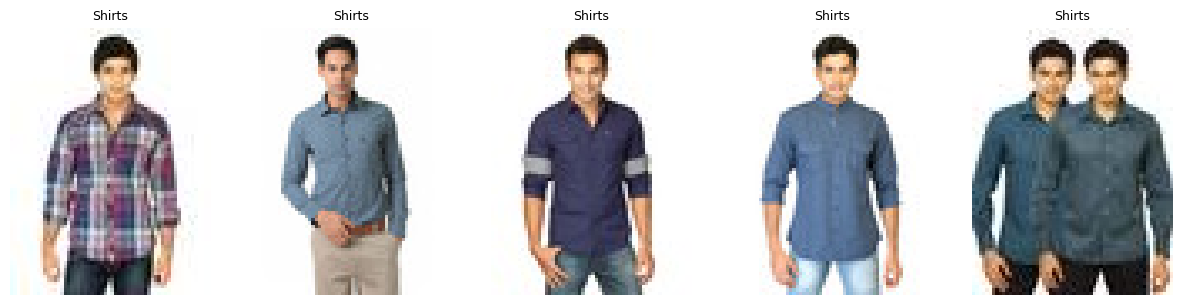

In [29]:
show_results("blue casual shirt")

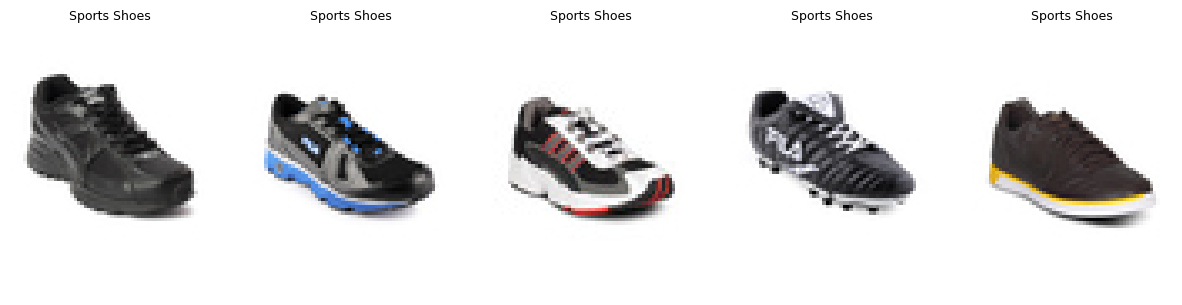

In [ ]:
show_results("black sports shoes")

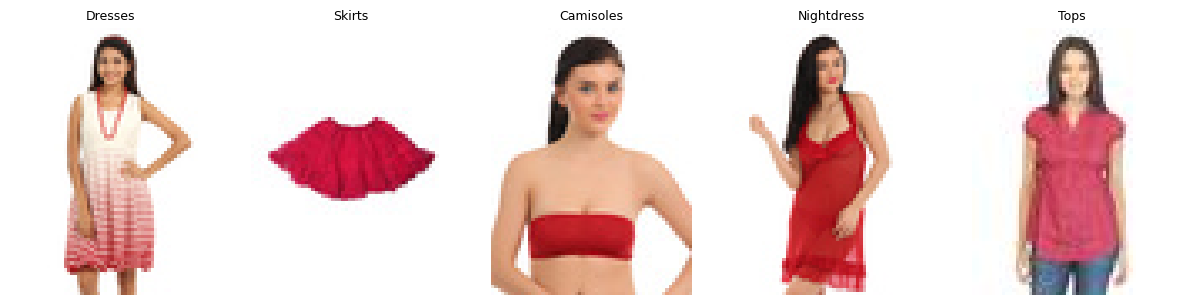

In [ ]:
show_results("red dress")

In [30]:
!pip install -q sentence-transformers

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [32]:
df = pd.read_csv("/content/styles.csv", on_bad_lines="skip")

In [33]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [34]:
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,317
productDisplayName,7


In [35]:
df = df.fillna("")

In [36]:

df["description"] = (
    df["productDisplayName"].astype(str) + " " +
    df["gender"].astype(str) + " " +
    df["masterCategory"].astype(str) + " " +
    df["subCategory"].astype(str) + " " +
    df["articleType"].astype(str) + " " +
    df["baseColour"].astype(str) + " " +
    df["season"].astype(str) + " " +
    df["usage"].astype(str)
)

In [37]:
df[["productDisplayName", "description"]].head()

,productDisplayName,description
0,Turtle Check Men Navy Blue Shirt,Turtle Check Men Navy Blue Shirt Men Apparel T...
1,Peter England Men Party Blue Jeans,Peter England Men Party Blue Jeans Men Apparel...
2,Titan Women Silver Watch,Titan Women Silver Watch Women Accessories Wat...
3,Manchester United Men Solid Black Track Pants,Manchester United Men Solid Black Track Pants ...
4,Puma Men Grey T-shirt,Puma Men Grey T-shirt Men Apparel Topwear Tshi...


In [38]:
small_df = df.iloc[:5000].copy()

In [39]:
model = SentenceTransformer("clip-ViT-B-32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [40]:
embeddings = model.encode(
    small_df["description"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [41]:
embeddings.shape

(5000, 512)

In [42]:
def search_products(query, top_k=5):

    # Convert query into embedding
    query_embedding = model.encode([query])

    # Compute cosine similarity
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    # Get indices of top matching products
    top_indices = similarities.argsort()[-top_k:][::-1]

    # Return matching products
    return small_df.iloc[top_indices], similarities[top_indices]

In [43]:
results, scores = search_products("blue casual shirt")

results[[
    "productDisplayName",
    "articleType",
    "baseColour",
    "usage",
    "subCategory",
    "season",
    "gender",
    "masterCategory"
]]

,productDisplayName,articleType,baseColour,usage,subCategory,season,gender,masterCategory
3678,Levis Men Check Blue Shirts,Shirts,Blue,Casual,Topwear,Fall,Men,Apparel
365,French Connection Women Blue Top,Tops,Blue,Casual,Topwear,Summer,Women,Apparel
506,Gini and Jony Boys Check Blue Shirt,Shirts,Blue,Casual,Topwear,Summer,Boys,Apparel
3731,Gini and Jony Boys Check Blue Shirt,Shirts,Blue,Casual,Topwear,Summer,Boys,Apparel
1928,Highlander Men Check Blue Shirt,Shirts,Blue,Casual,Topwear,Fall,Men,Apparel


In [44]:
results, scores = search_products("blue casual shirt")

for i in range(len(results)):
    print(f"{i+1}. {results.iloc[i]['productDisplayName']}")
    print(f"Similarity Score : {scores[i]:.4f}")
    print()

1. Levis Men Check Blue  Shirts
Similarity Score : 0.7218

2. French Connection Women Blue Top
Similarity Score : 0.7156

3. Gini and Jony Boys Check Blue Shirt
Similarity Score : 0.7060

4. Gini and Jony Boys Check Blue Shirt
Similarity Score : 0.7060

5. Highlander Men Check Blue Shirt
Similarity Score : 0.6979



In [45]:
def display_results(query, top_k=5):

    results, scores = search_products(query, top_k)

    plt.figure(figsize=(18,5))

    for i, (_, row) in enumerate(results.iterrows()):

        image_path = f"/content/images/{row['id']}.jpg"

        if os.path.exists(image_path):

            img = plt.imread(image_path)

            plt.subplot(1, top_k, i+1)
            plt.imshow(img)
            plt.axis("off")

            plt.title(
                f"{row['articleType']}\nScore:{scores[i]:.2f}",
                fontsize=9
            )

    plt.show()

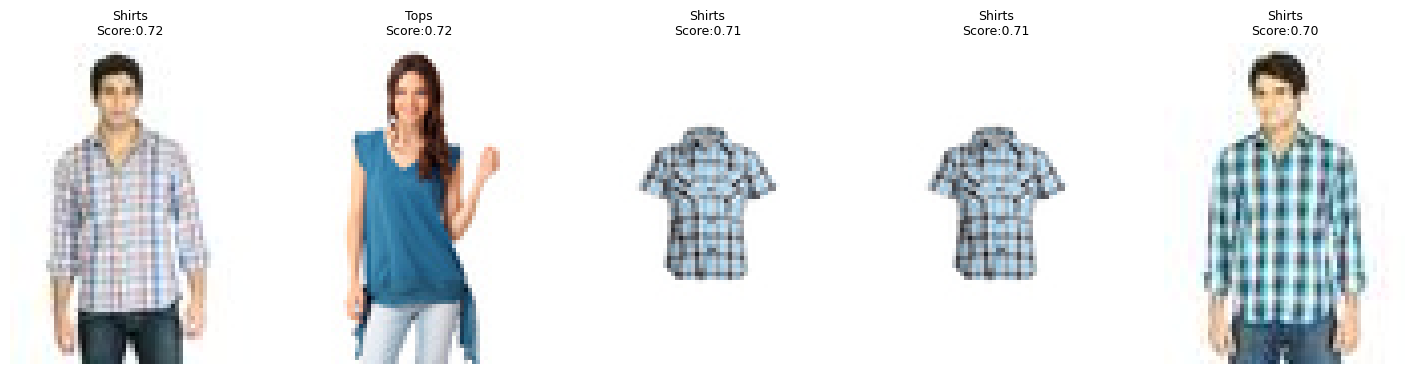

In [46]:
display_results("blue casual shirt")

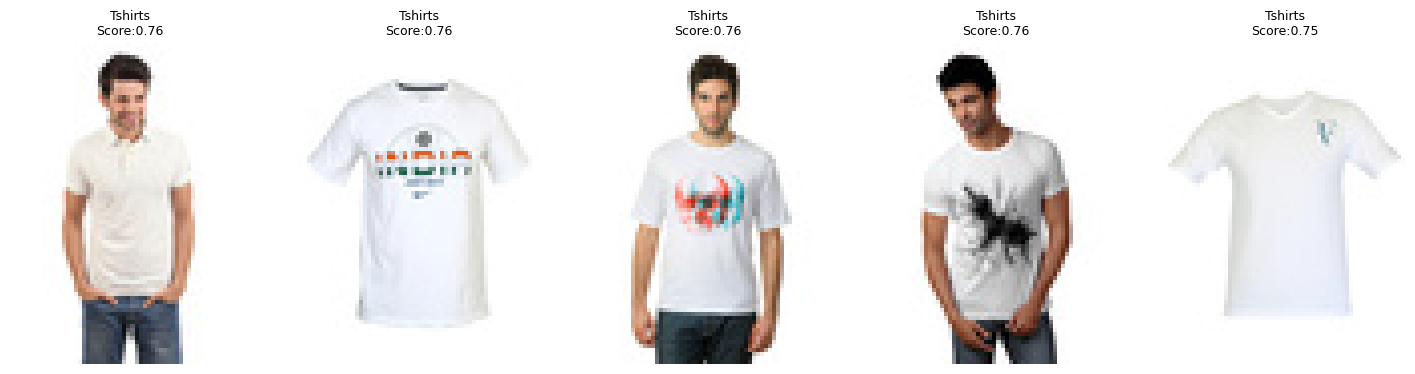

In [ ]:
display_results("white t shirt")

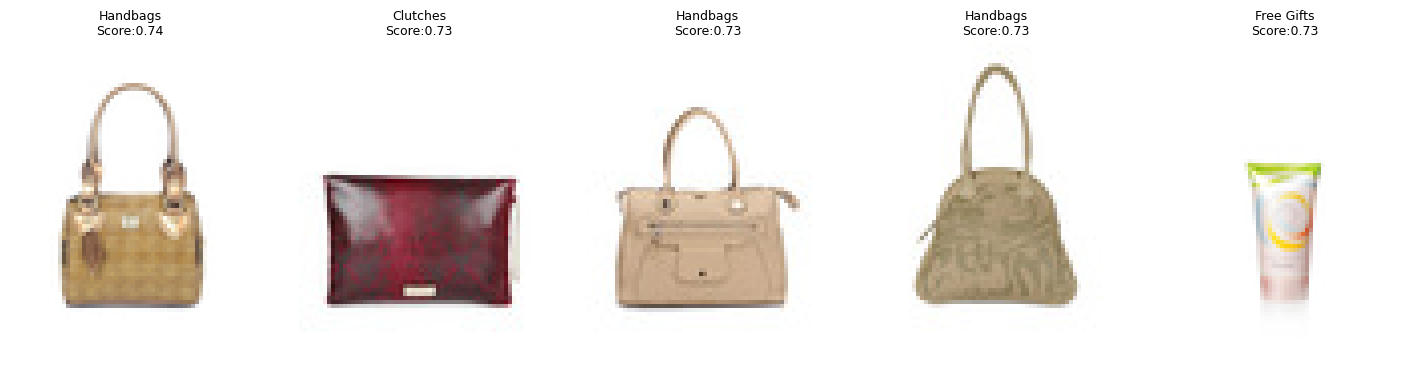

In [ ]:
display_results("women handbag")

In [47]:
results, scores = search_products("black sports shoes")

results[[
    "productDisplayName",
    "gender",
    "articleType",
    "baseColour",
    "usage"
]]

,productDisplayName,gender,articleType,baseColour,usage
205,ADIDAS Men Sports Black Sports Shoes,Men,Sports Shoes,Black,Sports
4163,ADIDAS Men Sports Black Sports Shoes,Men,Sports Shoes,Black,Sports
589,F Sports Men Black Pace Sports Shoes,Men,Sports Shoes,Black,Sports
3151,Numero Uno Men Black Shoes,Men,Casual Shoes,Black,Casual
2983,Numero Uno Men Black Shoes,Men,Casual Shoes,Black,Casual


<!-- GRADIO INTERFACE -->

<!-- GRADIO INTERFACE -->

Enter Product Description (type 'exit' to stop): red dress


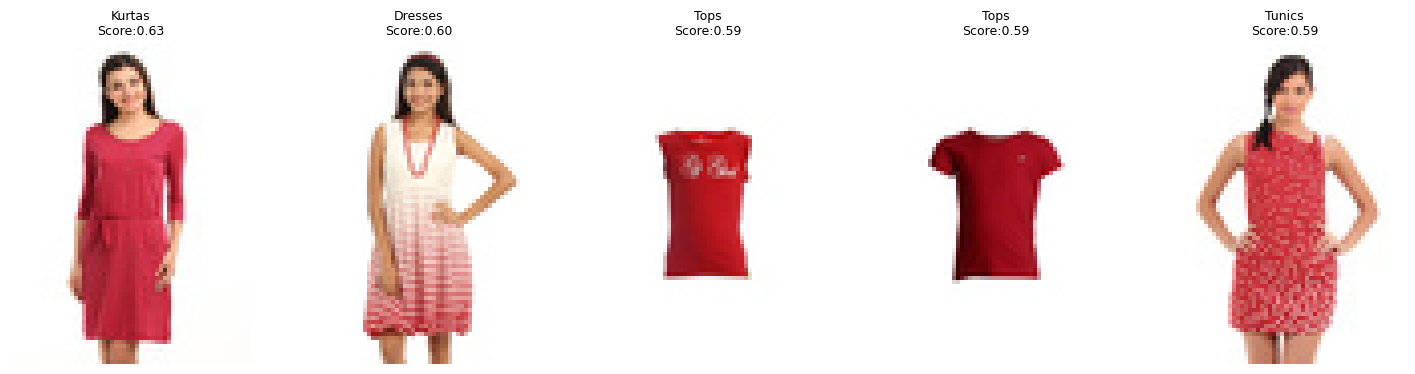

Enter Product Description (type 'exit' to stop): exit


In [48]:
while True:
    query = input("Enter Product Description (type 'exit' to stop): ")

    if query.lower() == "exit":
        break

    display_results(query)

In [49]:
!pip install -q gradio


In [50]:
import gradio as gr

In [51]:
def gradio_search(query):

    results, scores = search_products(query, top_k=5)

    gallery = []

    for i, (_, row) in enumerate(results.iterrows()):

        image_path = f"/content/images/{row['id']}.jpg"

        if os.path.exists(image_path):

            caption = (
                f"{row['productDisplayName']}\n"
                f"Similarity: {scores[i]:.2f}"
            )

            gallery.append((image_path, caption))

    return gallery

In [52]:
demo = gr.Interface(
    fn=gradio_search,

    inputs=gr.Textbox(
        lines=1,
        placeholder="Type something like 'black sports shoes'",
        label="Search Fashion Products"
    ),

    outputs=gr.Gallery(
        label="Recommended Products",
        columns=5,
        height=350
    ),

    title="👕 AI Reverse Product Search",

    description="""
Search fashion products using natural language.

Examples:
• blue casual shirt
• black sports shoes
• women handbag
• silver watch
• red dress
""",

    examples=[
        ["blue casual shirt"],
        ["black sports shoes"],
        ["women handbag"],
        ["silver watch"],
        ["red dress"]
    ]
)

In [53]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b18e88a0adcb96d87b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


gr.Markdown( """

👕 AI Reverse Product Search
This application allows users to search fashion products using natural language. The system uses the CLIP model to convert text into embeddings and retrieves the most similar products from the Fashion Product Images dataset. """ )

# Task 2: Unique Product Catalog Creation

In [54]:
from sklearn.cluster import DBSCAN

In [55]:
clustering = DBSCAN(
    eps=0.10,
    min_samples=1,
    metric="cosine"
)

labels = clustering.fit_predict(embeddings)

In [56]:
small_df["Cluster"] = labels

In [57]:
small_df[["productDisplayName", "Cluster"]].head(10)

,productDisplayName,Cluster
0,Turtle Check Men Navy Blue Shirt,0
1,Peter England Men Party Blue Jeans,1
2,Titan Women Silver Watch,2
3,Manchester United Men Solid Black Track Pants,3
4,Puma Men Grey T-shirt,4
5,Inkfruit Mens Chain Reaction T-shirt,5
6,Fabindia Men Striped Green Shirt,6
7,Jealous 21 Women Purple Shirt,7
8,Puma Men Pack of 3 Socks,8
9,Skagen Men Black Watch,9


In [58]:
print("Total Products :", len(small_df))
print("Unique Clusters:", small_df["Cluster"].nunique())

Total Products : 5000
Unique Clusters: 1566


In [59]:
for cluster_id in sorted(small_df["Cluster"].unique())[:5]:

    print("=" * 60)
    print("Cluster:", cluster_id)

    cluster_products = small_df[
        small_df["Cluster"] == cluster_id
    ]

    for product in cluster_products["productDisplayName"]:
        print(product)

Cluster: 0
Turtle Check Men Navy Blue Shirt
Cluster: 1
Peter England Men Party Blue Jeans
Tokyo Talkies Women Navy Slim Fit Jeans
Locomotive Men Washed Blue Jeans
Jealous 21 Women Washed Blue Jeans
Denizen Women Blue Jeans
Lee Men Blue Chicago Fit Jeans
Lee Men Blue Chicago Fit Jeans
Denizen Women Navy Blue Jeans
Lee Men Elvira Rinse Blue Chicago Fit Jeans
Locomotive Men Washed Blue Jeans
Lee Rinse Navy Blue Slim Fit Jeans
Lee Women Navy Blue Roxy Fit Jeans
John Players Men Blue Jeans
French Connection Men Blue Jeans
Jealous 21 Women Washed Blue Jeans
Jealous 21 Women Navy Blue Jeans
Lee Men Tino Blue Jeans
Spykar Women Ep Jeans Blue Jeans
Spykar Women Liana Blue Jeans
Jealous 21 Women Washed Blue Jeans
Lee Womens Blue Jeggings
Deni Yo Men Skinny Fit Blue Jeans
Spykar Women Washed Blue Jeans
Lee Men Blue Zed Fit Jeans
Locomotive Men Washed Blue Jeans
Lee Men Light Blue Chicago Fit Jeans
Peter England Men Blue Party Jeans
Flying Machine Men Midrise Blue Jeans
Jealous 21 Women Washed Lig

In [60]:
unique_catalog = (
    small_df
    .groupby("Cluster")
    .first()
    .reset_index()
)

In [61]:
print("Original Products :", len(small_df))
print("Unique Products   :", len(unique_catalog))

Original Products : 5000
Unique Products   : 1566


In [62]:
unique_catalog.to_csv(
    "unique_catalog.csv",
    index=False
)

In [63]:
unique_catalog[
    [
        "productDisplayName",
        "articleType",
        "baseColour"
    ]
].head(10)


,productDisplayName,articleType,baseColour
0,Turtle Check Men Navy Blue Shirt,Shirts,Navy Blue
1,Peter England Men Party Blue Jeans,Jeans,Blue
2,Titan Women Silver Watch,Watches,Silver
3,Manchester United Men Solid Black Track Pants,Track Pants,Black
4,Puma Men Grey T-shirt,Tshirts,Grey
5,Inkfruit Mens Chain Reaction T-shirt,Tshirts,Grey
6,Fabindia Men Striped Green Shirt,Shirts,Green
7,Jealous 21 Women Purple Shirt,Shirts,Purple
8,Puma Men Pack of 3 Socks,Socks,Navy Blue
9,Skagen Men Black Watch,Watches,Black


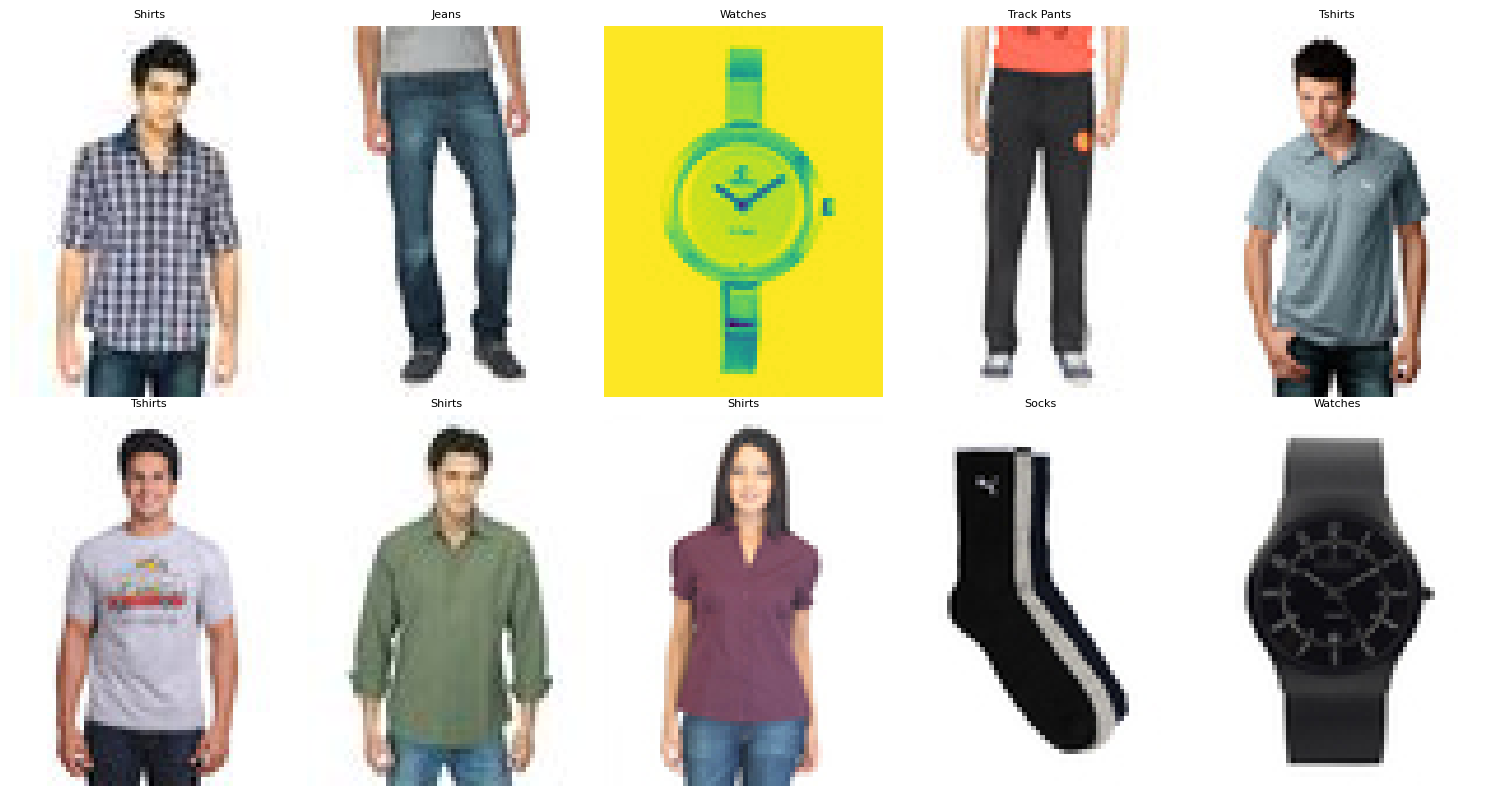

In [64]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(15, 8))

for i in range(10):

    row = unique_catalog.iloc[i]

    image_path = f"/content/images/{row['id']}.jpg"

    if os.path.exists(image_path):

        img = plt.imread(image_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["articleType"], fontsize=8)

plt.tight_layout()
plt.show()

In [65]:
clustered_products = (
    small_df
    .groupby("Cluster")["productDisplayName"]
    .apply(list)
)

clustered_products.head()

,productDisplayName
Cluster,
0,[Turtle Check Men Navy Blue Shirt]
1,"[Peter England Men Party Blue Jeans, Tokyo Tal..."
2,"[Titan Women Silver Watch, Police Men Black Di..."
3,[Manchester United Men Solid Black Track Pants]
4,"[Puma Men Grey T-shirt, Puma Men Grey T-shirt,..."


In [66]:
print("="*50)
print("Original Products :", len(small_df))
print("Unique Products   :", len(unique_catalog))
print("Duplicate Groups  :", small_df["Cluster"].nunique())
print("="*50)

Original Products : 5000
Unique Products   : 1566
Duplicate Groups  : 1566


In [67]:
cluster_id = 4

cluster = small_df[small_df["Cluster"] == cluster_id]

cluster[[
    "productDisplayName",
    "articleType",
    "baseColour"
]]

,productDisplayName,articleType,baseColour
4,Puma Men Grey T-shirt,Tshirts,Grey
373,Puma Men Grey T-shirt,Tshirts,Grey
674,Puma Men Puma runhard tee Grey Tshirts,Tshirts,Grey
733,Puma Men's Foundation Grey Polo T-shirt,Tshirts,Grey
2307,Puma Men's Foundation Grey Polo T-shirt,Tshirts,Grey


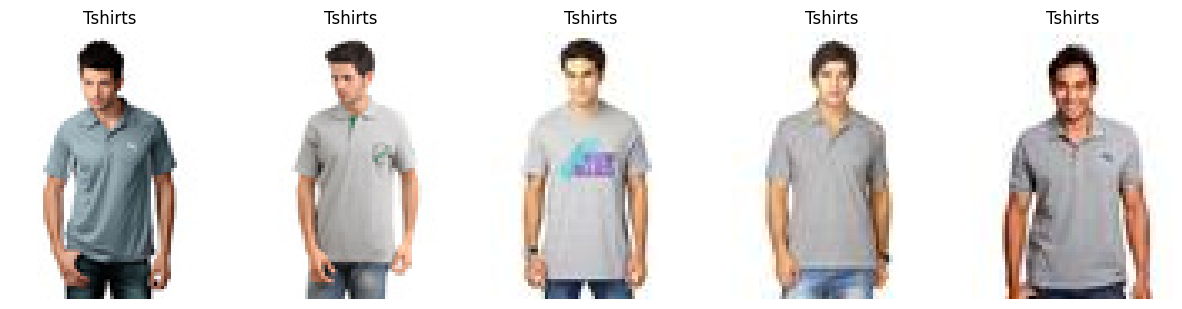

In [68]:
cluster_id = 4

cluster = small_df[small_df["Cluster"] == cluster_id]

plt.figure(figsize=(15,5))

for i, (_, row) in enumerate(cluster.head(5).iterrows()):

    path = f"/content/images/{row['id']}.jpg"

    if os.path.exists(path):

        img = plt.imread(path)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["articleType"])

plt.show()

In [69]:
unique_catalog.to_csv(
    "unique_catalog.csv",
    index=False
)

print("Unique catalog saved successfully!")

Unique catalog saved successfully!


In [70]:
unique_catalog.head(10)

,Cluster,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,description
0,0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,Turtle Check Men Navy Blue Shirt Men Apparel T...
1,1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,Peter England Men Party Blue Jeans Men Apparel...
2,2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,Titan Women Silver Watch Women Accessories Wat...
3,3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,Manchester United Men Solid Black Track Pants ...
4,4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,Puma Men Grey T-shirt Men Apparel Topwear Tshi...
5,5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,Inkfruit Mens Chain Reaction T-shirt Men Appar...
6,6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt,Fabindia Men Striped Green Shirt Men Apparel T...
7,7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt,Jealous 21 Women Purple Shirt Women Apparel To...
8,8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,Puma Men Pack of 3 Socks,Puma Men Pack of 3 Socks Men Accessories Socks...
9,9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Skagen Men Black Watch,Skagen Men Black Watch Men Accessories Watches...


In [71]:
print("Original Products :", len(small_df))
print("Unique Products :", len(unique_catalog))
print("Duplicates Removed :", len(small_df) - len(unique_catalog))

Original Products : 5000
Unique Products : 1566
Duplicates Removed : 3434


## Conclusion

Using CLIP embeddings and DBSCAN clustering, duplicate and near-duplicate
fashion products were identified and grouped together. A clean product
catalog containing only unique representative products was generated.
This approach can help e-commerce platforms reduce duplicate listings
and improve catalog quality.

# Task-1: Smart Product Recommendation Engine

In [72]:
small_df

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,description,Cluster
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,Turtle Check Men Navy Blue Shirt Men Apparel T...,0
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,Peter England Men Party Blue Jeans Men Apparel...,1
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,Titan Women Silver Watch Women Accessories Wat...,2
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,Manchester United Men Solid Black Track Pants ...,3
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,Puma Men Grey T-shirt Men Apparel Topwear Tshi...,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44573,Men,Footwear,Sandal,Sandals,Brown,Summer,2012.0,Casual,Coolers Men Brown Sandals,Coolers Men Brown Sandals Men Footwear Sandal ...,22
4996,37081,Women,Accessories,Bags,Handbags,Brown,Summer,2012.0,Casual,Lino Perros Women Brown Handbag,Lino Perros Women Brown Handbag Women Accessor...,13
4997,57958,Women,Apparel,Saree,Sarees,Green,Summer,2012.0,Ethnic,Prafful Green Printed Sari,Prafful Green Printed Sari Women Apparel Saree...,110
4998,5654,Men,Footwear,Shoes,Sports Shoes,White,Summer,2011.0,Sports,Reebok Men's Winning Stride White Shoe,Reebok Men's Winning Stride White Shoe Men Foo...,451


In [73]:
embeddings

array([[ 0.27373043,  0.15490776, -0.12254135, ...,  0.5153562 ,
         0.1208289 ,  0.2399337 ],
       [ 0.23502311, -0.08006001,  0.06057458, ...,  0.38753527,
         0.3072747 ,  0.4006954 ],
       [-0.188384  ,  0.20508069, -0.03550878, ...,  0.12484019,
         0.7279339 ,  0.00981265],
       ...,
       [ 0.08026849,  0.09845871, -0.28178793, ...,  0.61207604,
         0.02758327,  0.51216495],
       [-0.21169518, -0.27184463,  0.16180277, ...,  0.39335537,
        -0.01303131, -0.4326147 ],
       [ 0.3905254 ,  0.24548578, -0.11839187, ...,  0.16234298,
         0.48788303,  0.38734192]], dtype=float32)

In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


In [77]:
def recommend_products(product_name, top_k=5):

    # Search for product
    product = small_df[
        small_df["productDisplayName"].str.contains(
            product_name,
            case=False,
            na=False
        )
    ]

    if product.empty:
        print("Product not found.")
        return None

    # Selected product index
    idx = product.index[0]

    # Selected embedding
    query_embedding = embeddings[idx].reshape(1, -1)

    # Cosine similarity
    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    # Sort by similarity
    sorted_idx = similarities.argsort()[::-1]

    recommendations = []

    for i in sorted_idx:

        if i == idx:
            continue

        row = small_df.iloc[i].copy()

        row["Similarity"] = round(float(similarities[i]), 4)

        recommendations.append(row)

        if len(recommendations) == top_k:
            break

    return pd.DataFrame(recommendations)

In [78]:
recommendations = recommend_products(
    "Puma Men Grey T-shirt"
)

recommendations[
    [
        "productDisplayName",
        "articleType",
        "baseColour",
        "Similarity"
    ]
]

,productDisplayName,articleType,baseColour,Similarity
373,Puma Men Grey T-shirt,Tshirts,Grey,1.0000
674,Puma Men Puma runhard tee Grey Tshirts,Tshirts,Grey,0.9515
2307,Puma Men's Foundation Grey Polo T-shirt,Tshirts,Grey,0.9030
672,Nike Men Grey T-shirt,Tshirts,Grey,0.8983
733,Puma Men's Foundation Grey Polo T-shirt,Tshirts,Grey,0.8934


In [79]:
def show_recommendations(product_name):

    recommendations = recommend_products(product_name)

    if recommendations is None:
        return

    plt.figure(figsize=(18,5))

    for i, (_, row) in enumerate(recommendations.iterrows()):

        image_path = f"/content/images/{row['id']}.jpg"

        if os.path.exists(image_path):

            image = plt.imread(image_path)

            plt.subplot(1,5,i+1)

            plt.imshow(image)
            plt.axis("off")

            plt.title(
                f"{row['articleType']}\nScore:{row['Similarity']}",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

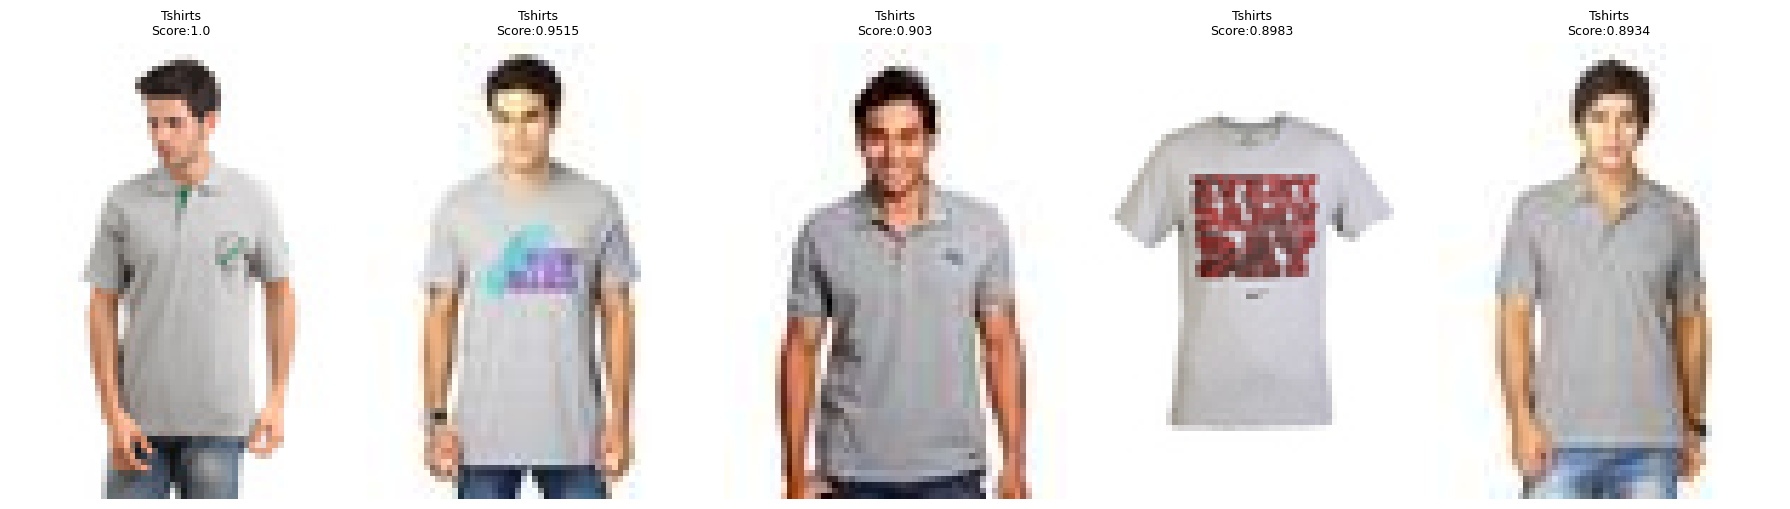

In [80]:
show_recommendations(
    "Puma Men Grey T-shirt"
)

Enter Product Name (type 'exit' to stop): puma men grey t shirt
Product not found.
Enter Product Name (type 'exit' to stop): Puma Men Grey T-shirt


,productDisplayName,articleType,Similarity
373,Puma Men Grey T-shirt,Tshirts,1.0000
674,Puma Men Puma runhard tee Grey Tshirts,Tshirts,0.9515
2307,Puma Men's Foundation Grey Polo T-shirt,Tshirts,0.9030
672,Nike Men Grey T-shirt,Tshirts,0.8983
733,Puma Men's Foundation Grey Polo T-shirt,Tshirts,0.8934


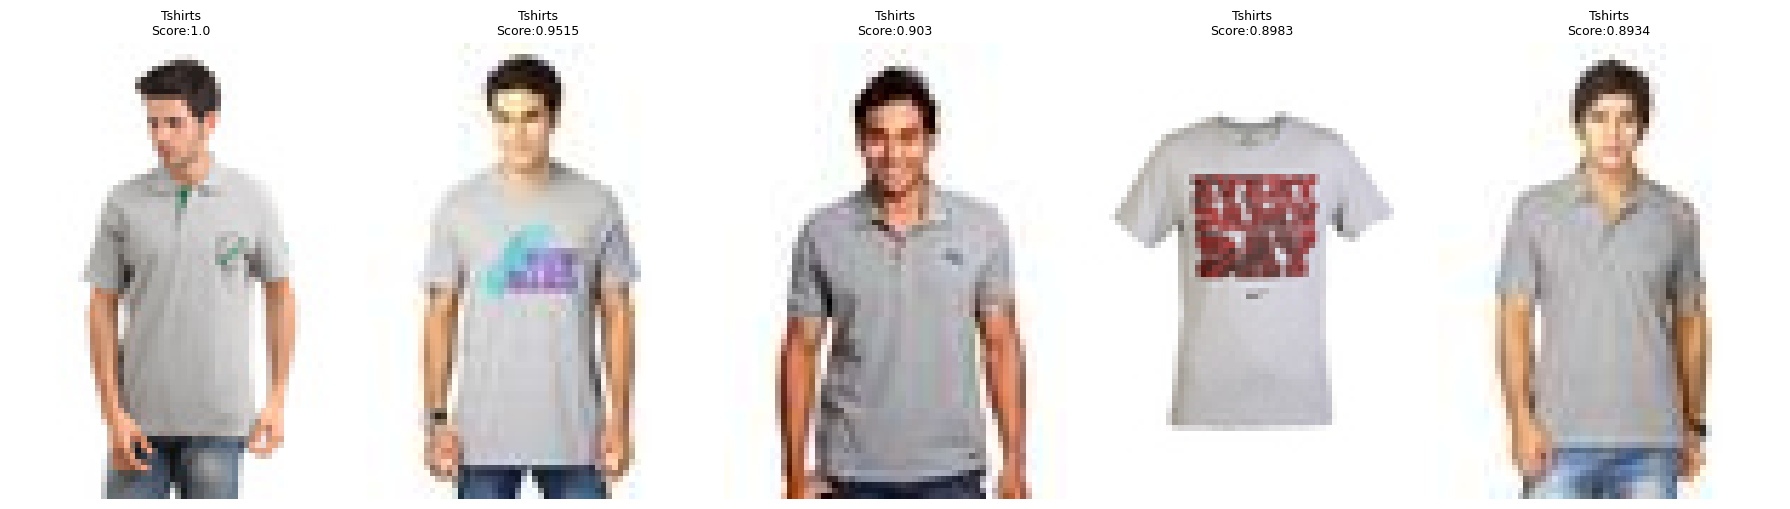

Enter Product Name (type 'exit' to stop): stop


,productDisplayName,articleType,Similarity
185,Colorbar Soft Touch Mousse Lipstick 025,Lipstick,0.9663
1433,Colorbar Full Finish Longwear Kiss Me Lipstick 07,Lipstick,0.9593
4147,Colorbar Soft Touch Brazil Nut Lipstick 024,Lipstick,0.9591
1027,Colorbar Soft Touch Wood Heart Lipstick 039,Lipstick,0.9494
760,Colorbar Soft Touch Spring Fling Lipstick 023,Lipstick,0.9172


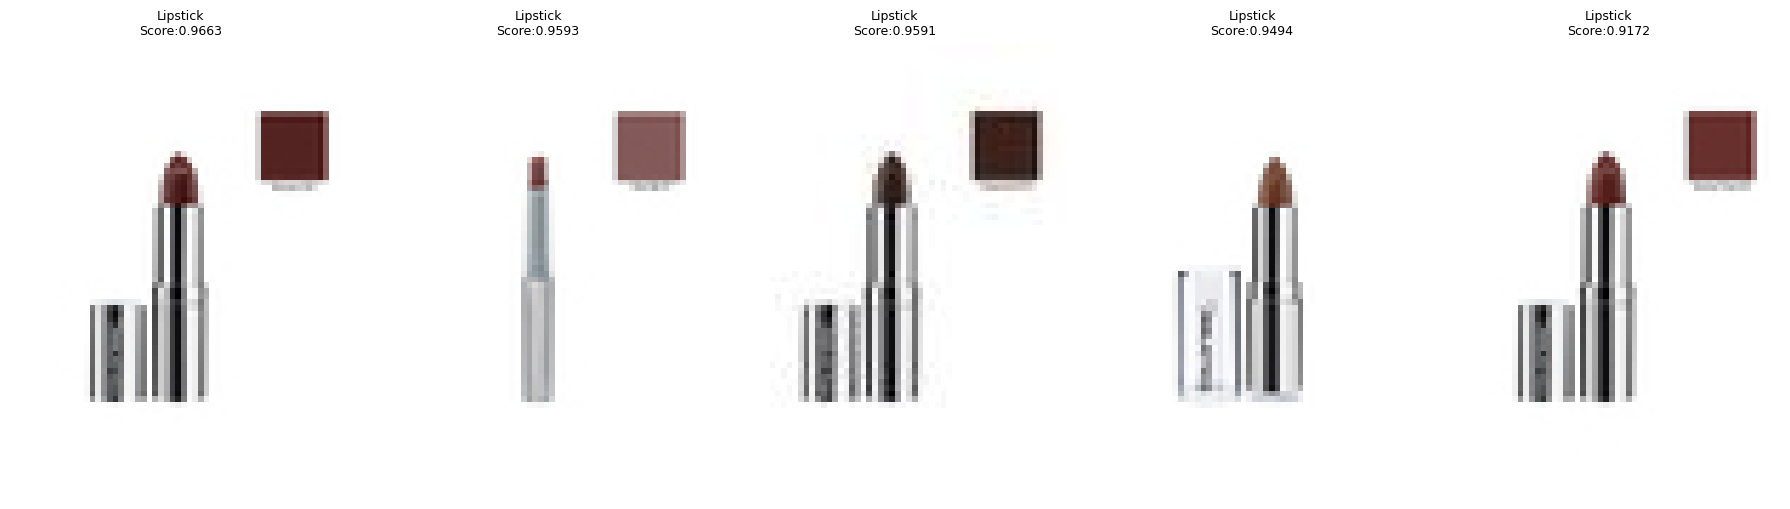

Enter Product Name (type 'exit' to stop): exit
Recommendation Engine Closed.


In [81]:
while True:

    product = input("Enter Product Name (type 'exit' to stop): ")

    if product.lower() == "exit":
        print("Recommendation Engine Closed.")
        break

    recommendations = recommend_products(product)

    if recommendations is not None:

        display(
            recommendations[
                [
                    "productDisplayName",
                    "articleType",
                    "Similarity"
                ]
            ]
        )

        show_recommendations(product)

Explanation
This recommendation engine uses CLIP embeddings generated from the fashion dataset. When a user selects a product, its embedding is compared with all other product embeddings using cosine similarity. Products with the highest similarity are retrieved. To encourage complementary recommendations instead of identical ones, products belonging to the same article type are excluded from the final results. The system then displays the top recommended products along with their images